## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001D4CA2A0080> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14624.000000,14325.000000,14624.000000,NaN,NaN,NaN,14325.000000,NaN,NaN,NaN,0.000000
1,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14049.000000,14193.000000,14336.500000,NaN,NaN,NaN,14259.000000,NaN,NaN,NaN,0.000000
2,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14240.666667,NaN,NaN,NaN,14197.333333,NaN,NaN,NaN,0.000000
3,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14192.750000,NaN,NaN,NaN,14166.500000,NaN,NaN,NaN,0.000000
4,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14164.000000,NaN,NaN,NaN,14148.000000,NaN,NaN,NaN,0.000000


In [6]:
timeline_file.shape

(3029224, 33)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [8]:
wnv_file.shape

(336, 4)

### Add mosquito predictions from trained model

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [11]:
dataset.dtypes

NUTS2_ID               object
NUTS2_NAME             object
NUTS3_ID               object
NUTS3_NAME             object
x                     float64
y                     float64
dt_placement           object
day                     int64
month                   int64
year                    int64
ndvi                  float64
ndmi                  float64
ndwi                  float64
ndbi                  float64
ndvi_mean             float64
ndmi_mean             float64
ndwi_mean             float64
ndbi_mean             float64
ndvi_std              float64
ndmi_std              float64
ndwi_std              float64
ndbi_std              float64
lst_day               float64
lst_night             float64
lst_day_jan_mean      float64
lst_day_feb_mean      float64
lst_day_mar_mean      float64
lst_day_apr_mean      float64
lst_night_jan_mean    float64
lst_night_feb_mean    float64
lst_night_mar_mean    float64
lst_night_apr_mean    float64
rainfall              float64
lst       

In [12]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [14]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [15]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [16]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [17]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [18]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

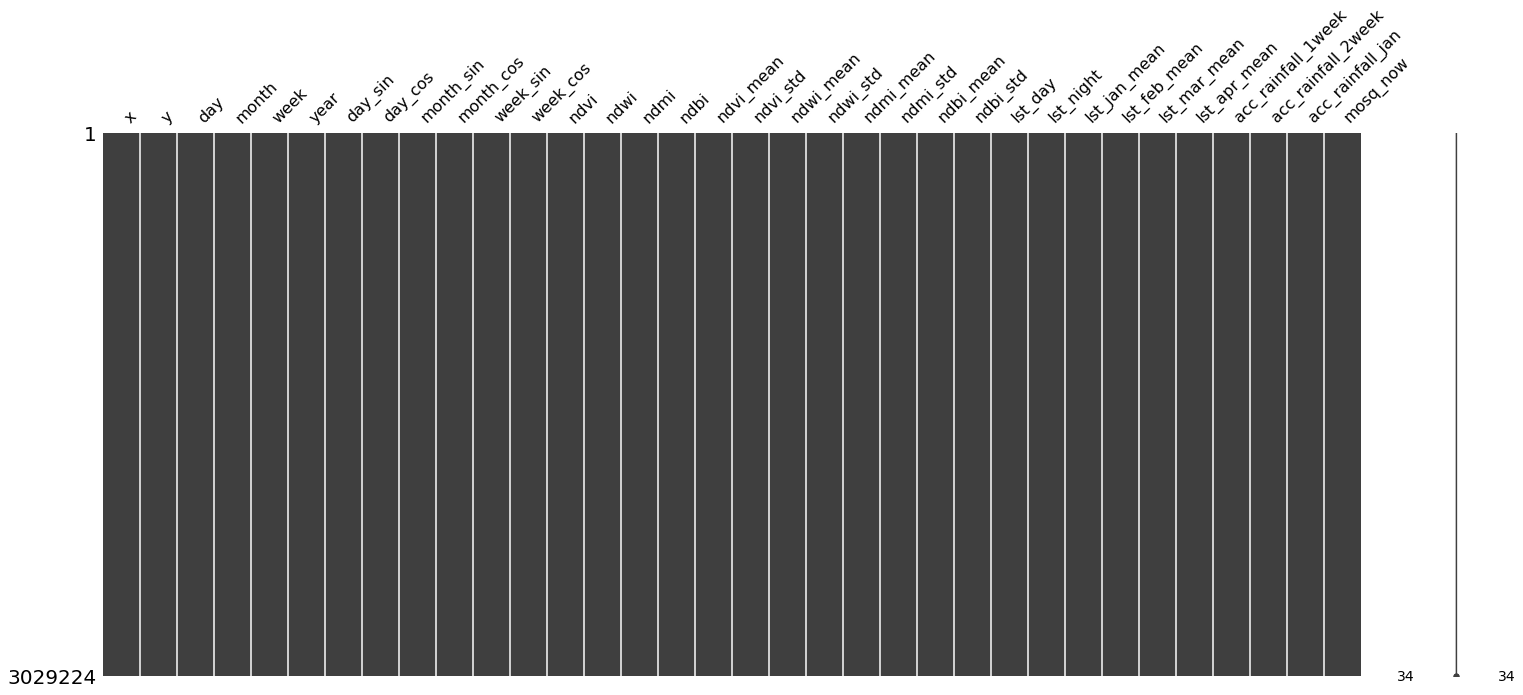

In [19]:
missingno.matrix(dataset_mamoth)

In [20]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [21]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [22]:
predictions = give_predictions(model, dataset_mamoth)

In [23]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.924050,36.226730,2010-01-01,399
1,22.924050,36.226730,2010-01-02,387
2,22.924050,36.226730,2010-01-03,388
3,22.924050,36.226730,2010-01-04,243
4,22.924050,36.226730,2010-01-05,272
...,...,...,...,...
3029219,24.050870,37.792680,2022-12-27,7
3029220,24.050870,37.792680,2022-12-28,1
3029221,24.050870,37.792680,2022-12-29,6
3029222,24.050870,37.792680,2022-12-30,6


<AxesSubplot:>

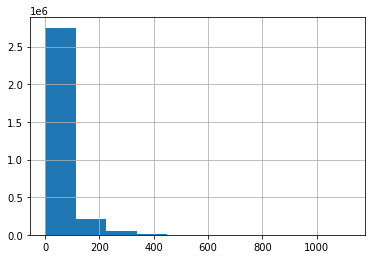

In [24]:
mosqutio_predictions.mosq_pred.hist()

In [25]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2010_2022.csv", encoding = enc, index = False)

In [26]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [27]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14540.000000,14327.000000,14540.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14433.500000,14433.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,399
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.000000,14327.000000,14464.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14358.000000,14395.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,387
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14327.000000,14428.666667,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14342.000000,14377.833333,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,388
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14164.000000,14327.000000,14362.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14245.500000,14344.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,243
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14348.000000,14180.000000,14359.600000,NaN,NaN,NaN,14297.600000,NaN,NaN,NaN,0.000000,14264.000000,14328.600000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-27,27,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14207.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14350.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.284521,767.502467,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,7
3029220,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.000000,14147.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14320.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.265016,767.502467,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3029221,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-29,29,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14149.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14321.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,0.012201,767.502467,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,6
3029222,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-30,30,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.0

In [28]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [29]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [30]:
dataset_locations

,x,y
0,22.924050,36.226730
1,22.924050,36.316560
2,22.924050,36.334530
3,22.946210,36.190790
4,22.946210,36.208760
...,...,...
633,24.028240,38.187950
634,24.028240,38.205910
635,24.050870,37.756750
636,24.050870,37.774710


In [31]:
dataset_locations_per_year

,x,y,year
0,22.924050,36.226730,2010
1,22.924050,36.226730,2011
2,22.924050,36.226730,2012
3,22.924050,36.226730,2013
4,22.924050,36.226730,2014
...,...,...,...
8289,24.050870,37.792680,2018
8290,24.050870,37.792680,2019
8291,24.050870,37.792680,2020
8292,24.050870,37.792680,2021


In [32]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [33]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.00889559413066443
Max distance: 44.08214172568856


In [34]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [35]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.924050,36.226730,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584
1,22.924050,36.316560,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
2,22.924050,36.334530,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
3,22.946210,36.190790,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
4,22.946210,36.208760,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584
...,...,...,...,...,...,...,...,...,...,...
633,24.028240,38.187950,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
634,24.028240,38.205910,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
635,24.050870,37.756750,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373
636,24.050870,37.774710,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373


In [36]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [37]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [38]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [39]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.924050,36.226730,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584
1,22.924050,36.316560,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
2,22.924050,36.334530,3064.642378,5125.907142,4,234.036351,320.424569,181.688808,0.000000,1.114475
3,22.946210,36.190790,3356.331183,1568.472969,4,239.051151,320.435120,175.997834,0.000000,12.286752
4,22.946210,36.208760,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584
...,...,...,...,...,...,...,...,...,...,...
633,24.028240,38.187950,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
634,24.028240,38.205910,1564.679149,3926.293406,16,78.273691,93.872007,172.002504,0.000000,1.987891
635,24.050870,37.756750,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373
636,24.050870,37.774710,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373


In [40]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [41]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [42]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [43]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [44]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [45]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2011
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2012
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2013
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2014
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2015
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2016
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2017
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2018
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2019
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2020
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2021
Min distance: 0.00889559413066443
Max distance: 44.08214172568856
Year: 2022
Min distance: 0.00889559413066443
Max distance: 44.08214172568856

In [46]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [47]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.924050,36.226730,2010,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
1,22.924050,36.316560,2010,22,81,20,81.000000,20,81,9,9,4,1,1,2,0
2,22.924050,36.334530,2010,22,81,20,81.000000,20,81,9,9,4,1,1,2,0
3,22.946210,36.190790,2010,22,92,20,92.000000,20,92,9,9,4,2,2,2,0
4,22.946210,36.208760,2010,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8289,24.028240,38.187950,2022,31,87,30,87.000000,30,87,10,10,1,6,6,2,0
8290,24.028240,38.205910,2022,31,87,30,87.000000,30,87,10,10,1,6,6,2,0
8291,24.050870,37.756750,2022,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
8292,24.050870,37.774710,2022,31,92,30,92.000000,30,92,10,10,1,6,6,2,0


In [48]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [49]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [50]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [51]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14540.000000,14327.000000,14540.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14433.500000,14433.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,399,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.000000,14327.000000,14464.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14358.000000,14395.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,387,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14327.000000,14428.666667,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14342.000000,14377.833333,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,388,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14164.000000,14327.000000,14362.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14245.500000,14344.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,243,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14348.000000,14180.000000,14359.600000,NaN,NaN,NaN,14297.600000,NaN,NaN,NaN,0.000000,14264.000000,14328.600000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,272,2548.281644,4341.250842,8,160.985125,358.681547,189.497127,0.000000,1.466584,22,77,20,77.000000,20,77,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-27,27,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14207.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14350.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.284521,767.502467,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,7,4946.096639,2677.272904,8,217.825269,235.291667,186.075871,0.000000,1.173373,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
3029220,EL30,αττικη,EL305,ανατολικη αττικη,24.050

In [52]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [53]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [54]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [55]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [56]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [57]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.806440,38.060430,1,1,2010,0.123323,0.109263,-0.267126,-0.109263,0.125316,0.037953,-0.263073,-0.201441,0.007934,0.007685,0.009721,0.007685,14551.000000,14257.000000,14551.000000,NaN,NaN,NaN,14257.000000,NaN,NaN,NaN,0.000000,14406.500000,14406.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,136,11583.374391,292.022047,2,182.342684,228.131012,182.543294,0.000000,1.000000,32,98,9,99.000000,30,98,13,13,10,8,9,2,0
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.692670,38.006530,1,1,2010,0.079589,-0.004166,-0.123803,-0.113856,0.071720,0.001537,-0.123091,-0.122310,0.000000,0.000000,0.000000,0.000000,14605.000000,14298.000000,14605.000000,NaN,NaN,NaN,14298.000000,NaN,NaN,NaN,0.000000,14420.000000,14420.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,203,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.000000,5.887334,1,98,9,99.000000,1,98,13,13,10,8,9,2,0
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.970590,1,1,2010,0.050770,0.011743,-0.051958,-0.340392,0.057835,0.021325,-0.132625,-0.268292,0.009923,0.004746,0.007215,0.004746,14589.000000,14304.000000,14589.000000,NaN,NaN,NaN,14304.000000,NaN,NaN,NaN,0.000000,14474.500000,14474.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,140,9967.604261,2195.498040,15,239.898712,262.905206,194.363331,0.000000,2.669538,1,89,9,97.000000,1,89,13,13,10,8,9,2,0
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.738180,37.898730,1,1,2010,0.056371,0.016556,-0.364932,-0.147609,0.067734,0.033771,-0.317579,-0.141008,0.011250,0.005561,0.006809,0.005561,14548.000000,14327.000000,14548.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14389.000000,14389.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,143,2801.690321,1232.926967,4,211.997473,80.771234,191.138144,0.000000,1.000000,32,97,9,99.000000,30,97,13,13,10,8,9,2,0
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.960330,38.223880,1,1,2010,0.397196,0.061491,-0.239368,-0.192189,0.133301,-0.042875,-0.337911,-0.396485,0.000000,0.000000,0.000000,0.000000,14551.000000,14292.000000,14551.000000,NaN,NaN,NaN,14292.000000,NaN,NaN,NaN,0.000000,14415.500000,14415.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,147,3550.918537,1175.728286,5,197.870739,77.441154,183.408973,0.000000,1.000000,31,91,30,91.000000,30,91,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.970590,31,12,2022,0.005039,-0.014784,-0.318086,-0.404157,0.041963,0.007657,-0.291912,-0.273265,0.024390,0.007097,0.015042,0.007097,14272.000000,14060.000000,14006.806452,14174.107143,14264.806452,14264.806452,13800.709677,13883.392857,13794.

In [58]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.760930,37.988560,1,1,2010,0.123323,0.031890,-0.267126,-0.221856,0.125316,0.037953,-0.263073,-0.201441,0.007934,0.007685,0.009721,0.007685,14514.000000,14136.000000,14514.000000,NaN,NaN,NaN,14136.000000,NaN,NaN,NaN,0.000000,14328.500000,14328.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,108,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,22,82,9,74.000000,20,82,10,10,1,6,6,2,0
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.624400,37.988560,1,1,2010,0.079589,-0.004166,-0.123803,-0.113856,0.071720,0.001537,-0.123091,-0.122310,0.000000,0.000000,0.000000,0.000000,14531.000000,14253.000000,14531.000000,NaN,NaN,NaN,14253.000000,NaN,NaN,NaN,0.000000,14420.000000,14420.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,159,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,1,73,9,73.000000,1,73,9,9,4,1,1,2,0
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.715420,37.934660,1,1,2010,0.050770,0.011743,-0.158866,-0.340392,0.057835,0.021325,-0.132625,-0.268292,0.009923,0.004746,0.007215,0.004746,14520.000000,14209.000000,14520.000000,NaN,NaN,NaN,14209.000000,NaN,NaN,NaN,0.000000,14364.500000,14364.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,104,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,1,78,9,89.000000,1,78,13,13,10,8,9,2,0
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.715420,37.880760,1,1,2010,0.056371,0.016556,-0.364932,-0.147609,0.067734,0.033771,-0.317579,-0.141008,0.011250,0.005561,0.006809,0.005561,14548.000000,14230.000000,14548.000000,NaN,NaN,NaN,14230.000000,NaN,NaN,NaN,0.000000,14389.000000,14389.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,143,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,1,58,9,79.000000,1,58,13,13,10,8,9,2,0
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.666090,37.684880,1,1,2010,0.149017,-0.115536,-0.407637,-0.396485,0.133301,-0.042875,-0.337911,-0.396485,0.000000,0.000000,0.000000,0.000000,14251.000000,13944.000000,14251.000000,NaN,NaN,NaN,13944.000000,NaN,NaN,NaN,0.000000,14097.500000,14097.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,60,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,11,70,9,70.000000,10,57,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.715420,37.934660,31,12,2022,0.005039,-0.014784,-0.318086,-0.404157,0.041963,0.007657,-0.291912,-0.273265,0.024390,0.007097,0.015042,0.007097,14272.000000,14004.000000,14006.806452,14174.107143,14264.806452,14264.806452,13800.709677,1388

In [59]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [60]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,1,2010,53,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,14546.611111,14247.111111,14396.861111,0.000000,147.388889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,1,2010,53,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,14608.222222,14287.000000,14447.611111,0.000000,187.444444,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,1,2010,53,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,14587.789474,14295.055556,14440.194444,0.000000,152.263158,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,1,2010,53,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,14618.700000,14318.600000,14468.650000,0.000000,169.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,1,2010,53,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14418.839721,0.000000,145.734483,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,31,30,30,10,10,1,6,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

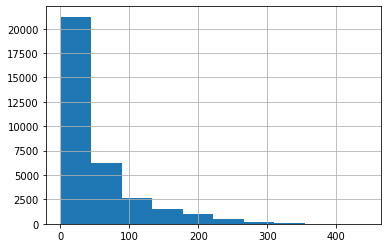

In [61]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [62]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

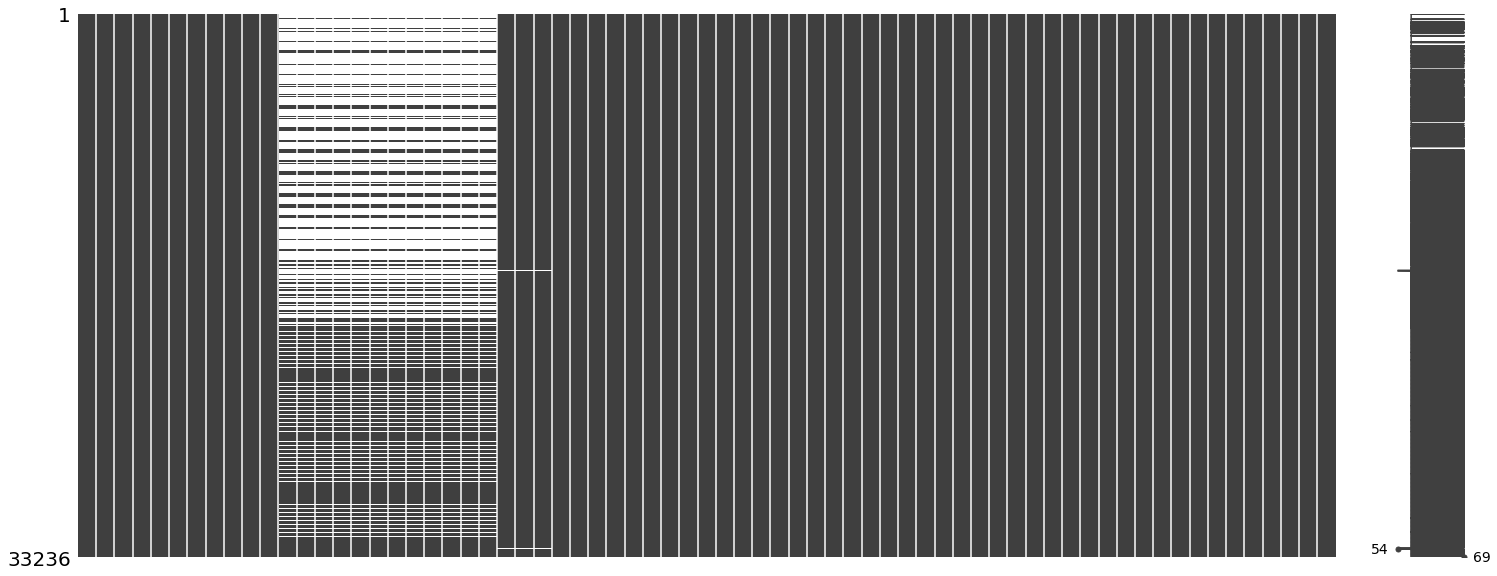

In [63]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [64]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [65]:
bio_values_df = pd.DataFrame(bio_values)

In [66]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,βορειος τομεας αθηνων,2010,1,0.578889,17.782222,120.039680
1,βορειος τομεας αθηνων,2010,2,0.042222,18.343333,129.209446
2,βορειος τομεας αθηνων,2010,3,4.820000,24.315556,59.665315
3,βορειος τομεας αθηνων,2010,4,8.447778,28.300000,11.268509
4,βορειος τομεας αθηνων,2010,5,13.584444,37.812222,47.016136
...,...,...,...,...,...,...
1087,"πειραιας, νησοι",2022,8,20.502000,40.619800,40.944603
1088,"πειραιας, νησοι",2022,9,15.164200,36.178400,65.431519
1089,"πειραιας, νησοι",2022,10,13.862200,32.449600,177.823883
1090,"πειραιας, νησοι",2022,11,7.858800,26.901200,316.207543


In [67]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [68]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,1,2010,53,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,17.782222,11.792222,14.787222,0.000000,147.388889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,1,2010,53,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,19.014444,12.590000,15.802222,0.000000,187.444444,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,1,2010,53,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,18.605789,12.751111,15.678450,0.000000,152.263158,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,1,2010,53,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,19.224000,13.222000,16.223000,0.000000,169.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2,-2.668000,19.224000,110.246915
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,1,2010,53,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,18.574390,11.846828,15.210609,0.000000,145.734483,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000

<AxesSubplot:>

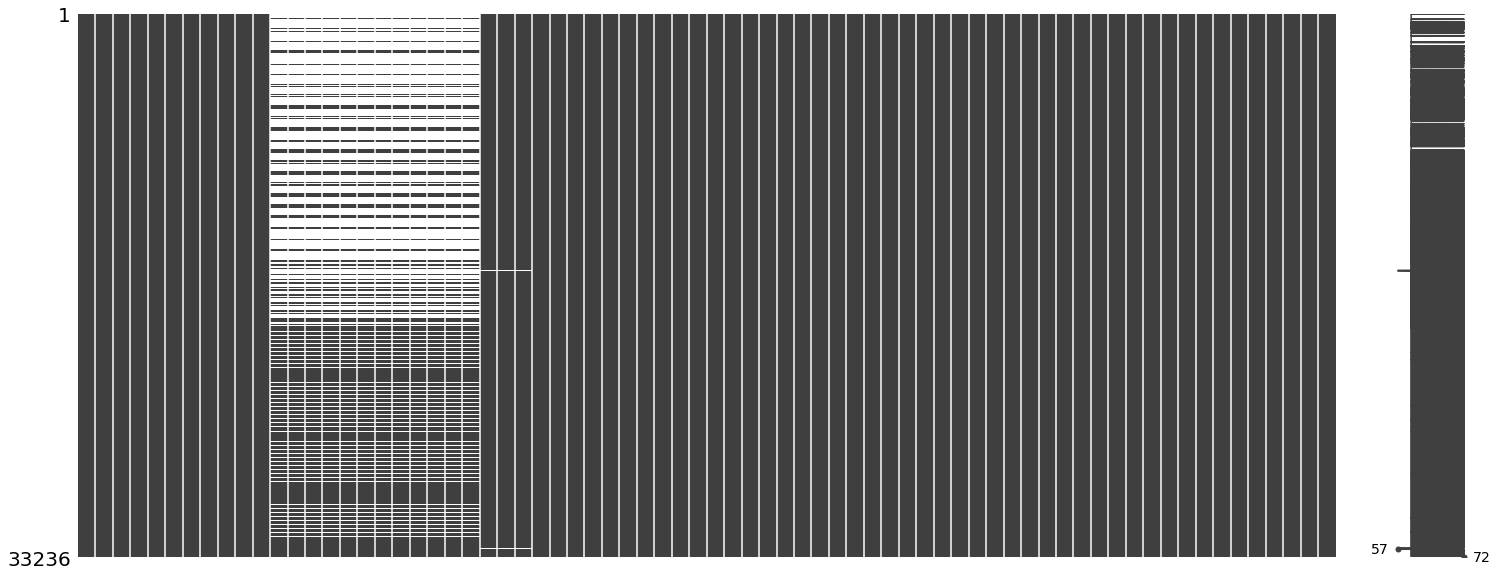

In [69]:
missingno.matrix(dataset)

In [70]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [71]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [72]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,1,2010,53,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,17.782222,11.792222,14.787222,0.000000,147.388889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680,2010-01
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,1,2010,53,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,19.014444,12.590000,15.802222,0.000000,187.444444,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405,2010-01
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,1,2010,53,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,18.605789,12.751111,15.678450,0.000000,152.263158,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420,2010-01
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,1,2010,53,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,19.224000,13.222000,16.223000,0.000000,169.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2,-2.668000,19.224000,110.246915,2010-01
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,1,2010,53,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,18.574390,11.846828,15.210609,0.000000,145.734483,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.

In [73]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,1,2010,1,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,8.254444,7.056667,4.416667,0.000000,21.444444,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680
1,1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,1,2010,1,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,10.805556,8.136667,6.235556,0.000000,21.111111,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405
2,2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,1,2010,1,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,10.288947,8.174211,5.494211,0.000000,21.263158,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420
3,3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,1,2010,1,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,5.970000,8.062000,2.689000,0.000000,20.500000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2,-2.668000,19.224000,110.246915
4,4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,1,2010,1,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,12.267103,1.772276,4.504345,0.000000,18.889655,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,31,30,30

In [74]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [75]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,8.761039,3.872248,2164.888889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,10.493728,3.617110,2596.888889,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,9.753346,3.644949,2375.526316,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,9.072484,3.556352,2468.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2,-2.668000,19.224000,110.246915
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,8.701736,3.905487,2098.851724,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,31,30,30,10,10,1,6,6,2,1.772276,18.57439

In [76]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [77]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1092 non-null   period[M]
 1   NUTS2_ID                1092 non-null   object   
 2   NUTS2_NAME              1092 non-null   object   
 3   NUTS3_ID                1092 non-null   object   
 4   NUTS3_NAME              1092 non-null   object   
 5   x                       1092 non-null   float64  
 6   y                       1092 non-null   float64  
 7   month                   1092 non-null   int64    
 8   year                    1092 non-null   int64    
 9   ndvi                    1078 non-null   float64  
 10  ndmi                    1078 non-null   float64  
 11  ndwi                    1078 non-null   float64  
 12  ndbi                    1078 non-null   float64  
 13  ndvi_mean               1081 non-null   float64  
 14  ndmi_mea

In [78]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    336 non-null    object
 1   NUTS3_NAME    336 non-null    object
 2   dt_placement  336 non-null    object
 3   cases         336 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 10.6+ KB


In [79]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [80]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5
...,...,...,...,...
331,αττικη,"πειραιας, νησοι",2021-06,0
332,αττικη,"πειραιας, νησοι",2021-07,0
333,αττικη,"πειραιας, νησοι",2021-08,0
334,αττικη,"πειραιας, νησοι",2021-09,0


In [81]:
wnv_file['cases'].value_counts()

0     269
1      35
4       5
8       4
5       4
7       3
2       3
6       2
3       2
11      1
15      1
10      1
18      1
16      1
12      1
33      1
9       1
20      1
Name: cases, dtype: int64

In [82]:
wnv_file.cases.sum()

296

In [83]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [84]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,8.761039,3.872248,2164.888889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,10.493728,3.617110,2596.888889,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,9.753346,3.644949,2375.526316,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420,NaN
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,9.072484,3.556352,2468.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1201.680323,846.829282,4,193.007697,50.292710,184.080518,0.000000,1.000000,5478.764318,2273.636609,18,248.470446,342.475832,209.606026,0.000000,10.672627,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,32,9,30,13,13,10,8,9,2,-2.668000,19.224000,110.246915,NaN
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,8.701736,3.905487,2098.851724,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,1463.842586,704.878405,0,46.612082,10.281783,144.918596,0.000000,1.000000,14851.982470,4990.696950,30,290.209538,1146.846674,199.398115,0.000000,19.623685,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,31,30,30,10,10,1,6

In [85]:
merged = fillna(merged,{'cases': 0})

In [86]:
merged['cases'].value_counts()

0.000000     1025
1.000000       35
4.000000        5
8.000000        4
5.000000        4
7.000000        3
2.000000        3
6.000000        2
3.000000        2
10.000000       1
33.000000       1
18.000000       1
9.000000        1
16.000000       1
20.000000       1
15.000000       1
12.000000       1
11.000000       1
Name: cases, dtype: int64

In [87]:
merged.cases.sum()

296.0

In [88]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

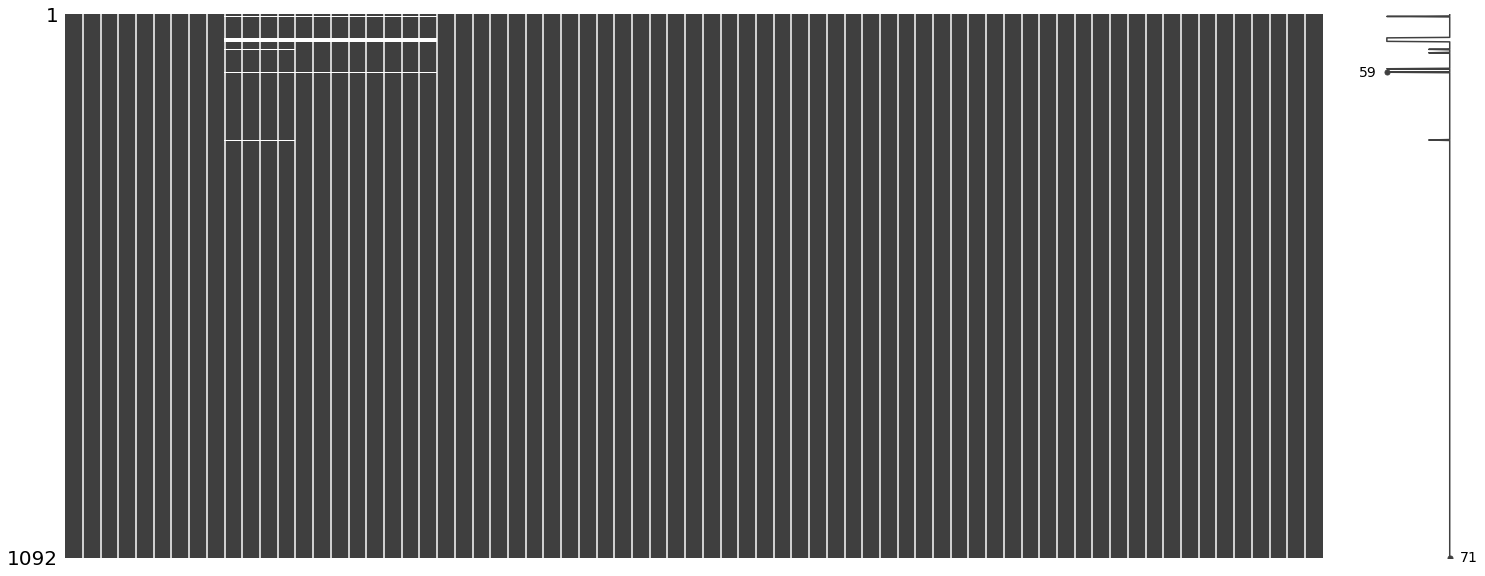

In [89]:
missingno.matrix(merged)

In [90]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

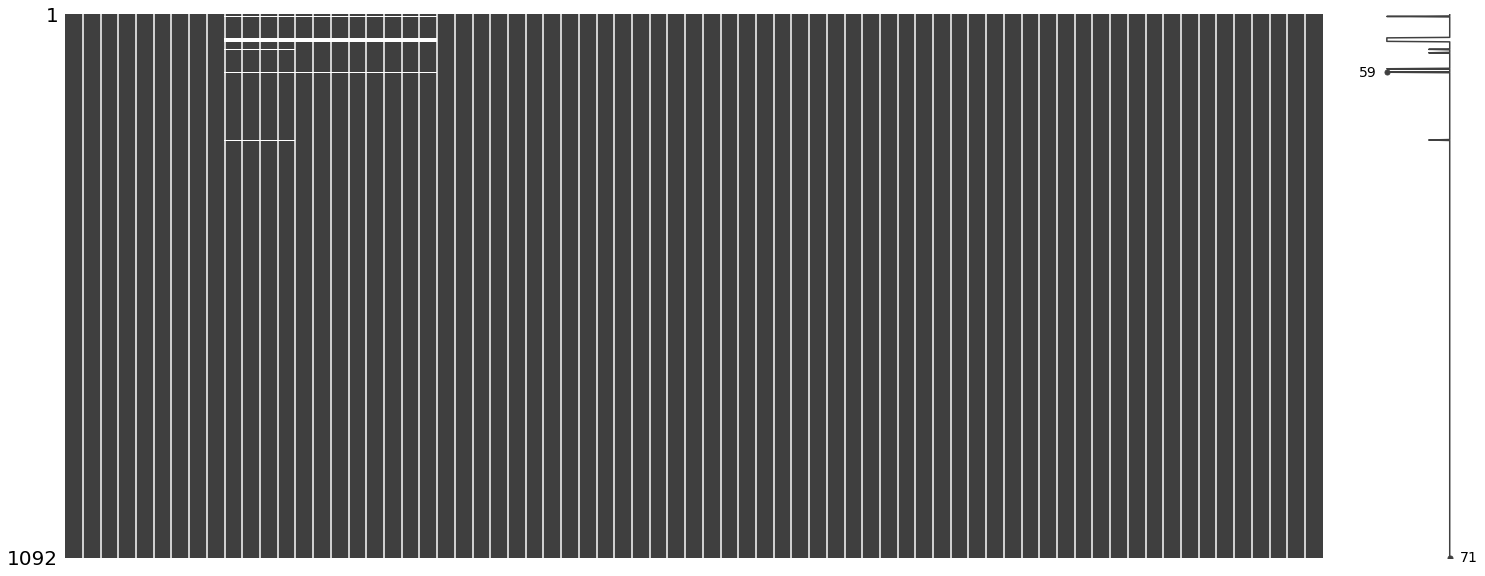

In [91]:
missingno.matrix(merged)

In [92]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [93]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['βορειος τομεας αθηνων', 'δυτικος τομεας αθηνων',
       'κεντρικος τομεας αθηνων', 'νοτιος τομεας αθηνων',
       'ανατολικη αττικη', 'δυτικη αττικη', 'πειραιας, νησοι'],
      dtype=object)

In [94]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [95]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,βορειος τομεας αθηνων,2010,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000
1,δυτικος τομεας αθηνων,2010,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000
2,κεντρικος τομεας αθηνων,2010,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000
3,νοτιος τομεας αθηνων,2010,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000
4,ανατολικη αττικη,2010,19.416667,21.000000,47.727273,855.685088,44.000000,0.000000,44.000000,14.500000,30.500000,30.500000,9.333333,868.000000,219.000000,0.000000,83.901842,363.000000,71.000000,71.000000,342.000000
5,δυτικη αττικη,2010,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
6,"πειραιας, νησοι",2010,19.958333,18.250000,45.625000,788.110033,42.000000,2.000000,40.000000,15.833333,29.333333,30.000000,10.500000,1370.000000,362.000000,2.000000,88.219002,630.000000,95.000000,125.000000,511.000000
7,βορειος τομεας αθηνων,2011,18.166667,19.000000,45.238095,899.579026,42.000000,0.000000,42.000000,9.500000,29.500000,30.000000,8.500000,1240.000000,317.000000,0.000000,87.859478,635.000000,18.000000,79.000000,622.000000
8,δυτικος τομεας αθηνων,2011,19.500000,19.333333,42.962963,967.658843,43.000000,-2.000000,45.000000,9.333333,31.166667,32.166667,8.833333,1236.000000,326.000000,0.000000,89.842707,653.000000,23.000000,70.000000,630.000000
9,κεντρικος τομεας αθηνων,2011,19.041667,18.416667,42.829457,908.910020,42.000000,-1.000000,43.000000,9.666667,30.166667,30.666667,9.166667,1198.000000,310.000000,0.000000,89.519105,629.000000,20.000000,70.000000,612.000000


In [96]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [97]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'δυτικη αττικη')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
5,2010-01,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.584146,4.510271,7.547208,3.646743,2345.364583,7712.534709,2113.242711,12.151042,158.875405,443.755753,178.037408,0.000000,4.230376,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3744.414150,897.989029,6.269105,45.856227,233.335651,7.841125,0.000000,6.421563,31,30,30,10,10,1,6,6,2,-0.195625,18.126230,113.049047,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
12,2010-02,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,2,2010,0.308002,0.081885,-0.216865,-0.081885,0.302355,0.083829,-0.211749,-0.083829,0.022534,0.013486,0.016906,0.013486,12.437344,5.508661,8.973002,4.175904,468.942708,7712.534709,2113.242711,12.151042,158.875405,443.755753,178.037408,0.000000,4.230376,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3744.414150,897.989029,6.269105,45.856227,233.335651,7.841125,0.000000,6.421563,31,30,30,10,10,1,6,6,2,-0.503021,17.528958,116.925310,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
19,2010-03,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,3,2010,0.365500,0.086692,-0.286407,-0.086692,0.366304,0.087960,-0.285143,-0.087960,0.032168,0.029559,0.026162,0.029559,17.719721,7.866250,12.792986,2.329068,1112.166667,7712.534709,2113.242711,12.151042,158.875405,443.755753,178.037408,0.000000,4.230376,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3744.414150,897.989029,6.269105,45.856227,233.335651,7.841125,0.000000,6.421563,31,30,30,10,10,1,6,6,2,3.700000,22.775104,72.201094,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
26,2010-04,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,4,2010,0.386130,0.100389,-0.287597,-0.100389,0.383222,0.098423,-0.288289,-0.098423,0.033698,0.034967,0.030706,0.034967,21.909458,9.046431,15.477944,0.427672,2377.453125,7712.534709,2113.242711,12.151042,158.875405,443.755753,178.037408,0.000000,4.230376,1417.864828,22.037377,2,68.141087,28.831878,159.616427,0.000000,1.000000,13994.719513,4448.949836,22,229.104691,1061.620126,195.847139,0.000000,37.848946,3744.414150,897.989029,6.269105,45.856227,233.335651,7.841125,0.000000,6.421563,31,30,30,10,10,1,6,6,2,6.271563,27.701875,12.830148,0

In [98]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [99]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [100]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [101]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [102]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

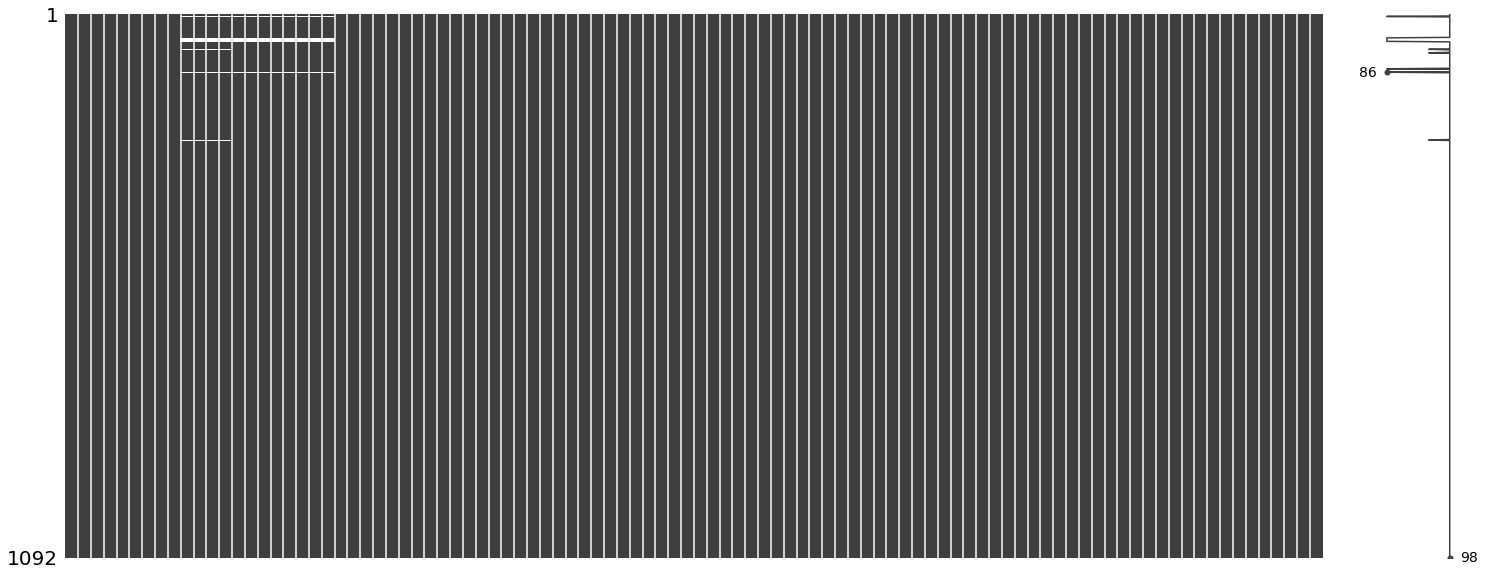

In [103]:
missingno.matrix(dataset)

In [104]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [105]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [106]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [107]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [108]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

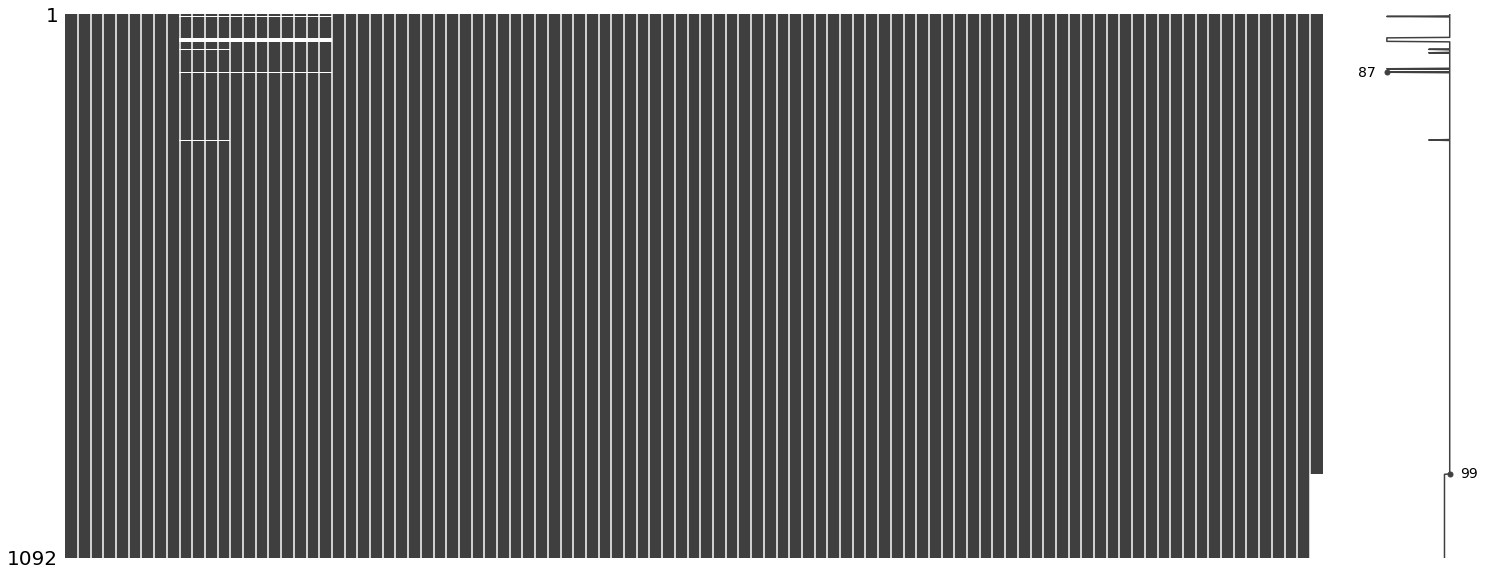

In [109]:
missingno.matrix(dataset)

In [110]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [111]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [112]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [113]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [114]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

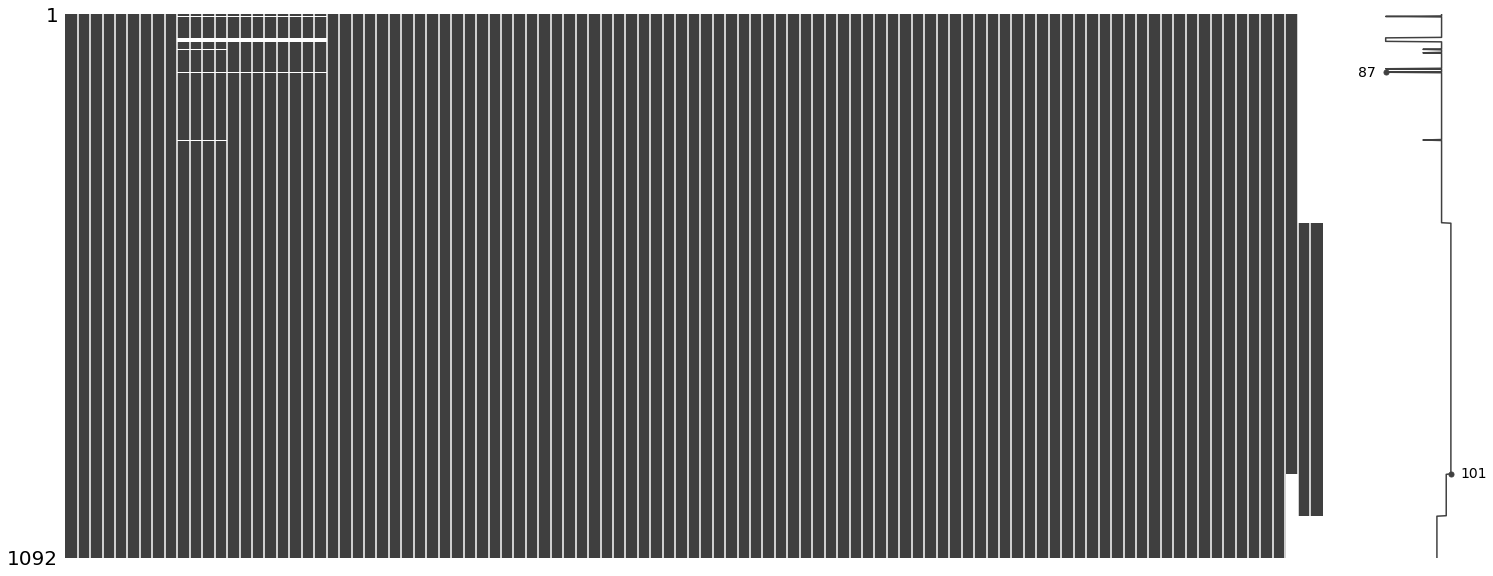

In [115]:
missingno.matrix(dataset)

In [116]:
missing = describe_dataframe(dataset)

In [117]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,0.000000
97,F_TOTAL,0.000000
98,MIO_EUR,15.384600
99,L_TOTAL,46.153800


In [118]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,8.761039,3.872248,2164.888889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680,0,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,10.493728,3.617110,2596.888889,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405,0,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,9.753346,3.644949,2375.526316,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420,0,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN
3,2010-01,EL30,αττικη,E

In [119]:
dataset.reset_index(inplace=True, drop=True)

In [120]:
dataset['cases'].value_counts()

0     1025
1       35
4        5
8        4
5        4
7        3
2        3
6        2
3        2
10       1
33       1
18       1
9        1
16       1
20       1
15       1
12       1
11       1
Name: cases, dtype: int64

In [121]:
dataset['cases'].sum()

296

In [122]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,8.761039,3.872248,2164.888889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.000000,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680,0,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,10.493728,3.617110,2596.888889,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.000000,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405,0,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,9.753346,3.644949,2375.526316,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.000000,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420,0,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN
3,2010-01,EL30,αττικη,E

In [123]:
cols = dataset.columns

In [124]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [125]:
len(cols)

101

In [126]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc, index = False)
